<img src="../assets/ga-logo.png" style="float: left; margin: 20px; height: 55px">

# Logistic Regression Practice

---

# Titanic
On April 15, 1912, the RMS Titanic sank after colliding with an iceberg, killing over 1,500 of its 2,224 passengers and crew. Survival wasn't random — factors like class, sex, and age all played a role in who made it into a lifeboat.

You will be predicting `Survived`: whether a passenger survived (1) or did not (0), using their ticket and demographic information.

# Imports

In [1]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.dummy import DummyClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report, accuracy_score, recall_score, precision_score, f1_score

### 1. Load the data

Read in the `titanic.csv` data.

In [2]:
# TODO:
titanic = pd.read_csv('./data/titanic.csv')
titanic

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


### 2. Drop columns that won’t help the model

> `PassengerId` is just a row ID, `Name` and `Ticket` are high-cardinality free text, and `Cabin` is missing for the vast majority of passengers.

In [3]:
# TODO:
titanic = titanic.drop(columns = ['PassengerId','Name','Ticket','Cabin'])
titanic

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S
...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000,S
887,1,1,female,19.0,0,0,30.0000,S
888,0,3,female,NaN,1,2,23.4500,S
889,1,1,male,26.0,0,0,30.0000,C


### 3. Handle missing values

> Check for missing values. `Age` and `Embarked` both have null values, fill them in (median for `Age` and the most common value for `Embarked`).

In [4]:
# TODO:
titanic['Age'] = titanic['Age'].fillna(titanic['Age'].median())
titanic['Embarked'] = titanic['Embarked'].fillna(titanic['Embarked'].mode()[0])
titanic.isnull().sum()

Survived    0
Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    0
dtype: int64

# Modeling

### 4. Set up your target and features, and split into training and testing sets

Set `Survived` as your target, `y`. Everything else remaining is your feature matrix, `X`.

In [5]:
# TODO:
X = titanic.drop(columns = ['Survived'])
y = titanic['Survived']

In [6]:
X.head()


,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,3,male,22.0,1,0,7.2500,S
1,1,female,38.0,1,0,71.2833,C
2,3,female,26.0,0,0,7.9250,S
3,1,female,35.0,1,0,53.1000,S
4,3,male,35.0,0,0,8.0500,S


In [7]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.25,random_state=42)

### 5. Establish a baseline

What accuracy would you get by always predicting the majority class? This is the number your model needs to beat.

In [8]:
# TODO:
dummy = DummyClassifier(strategy= 'most_frequent')
dummy.fit(X_train,y_train)
print(F"Baseline Accuracy: {dummy.score(X_test,y_test):.4f}")

Baseline Accuracy: 0.6009


### 6. Build a `Pipeline` with a `ColumnTransformer`

> Use a `ColumnTransformer` to scale your numeric features and encode your categorical features. Then chain it into a `Pipeline`.

In [9]:
# TODO:
num_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()

preprocessor = ColumnTransformer(
    transformers=[
        ('num',StandardScaler(),num_cols),
        ('cat',OneHotEncoder(drop = 'first', handle_unknown='ignore',sparse_output=False),cat_cols)
    ]
)

pipeline = Pipeline(
    steps=[
        ('preprocessing', preprocessor),
        ('model', LogisticRegression(random_state=42))
    ]
)

C:\Users\a0355\AppData\Local\Temp\ipykernel_4888\4240668926.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()


### 7. Fit your pipeline and evaluate train vs. test accuracy

Is there a meaningful gap between train and test performance? Is this model better than the null model?

In [11]:
# TODO:
pipeline.fit(X_train,y_train)
print(f"Train Score: {pipeline.score(X_train,y_train)}")
print(f"Test Score: {pipeline.score(X_test,y_test)}")

Train Score: 0.7979041916167665
Test Score: 0.8071748878923767


### 8. Confusion matrix

> Generate a confusion matrix for your model's predictions on the test set. Which type of mistake is your model making more (predicting survival for someone who didn't, or the reverse?)

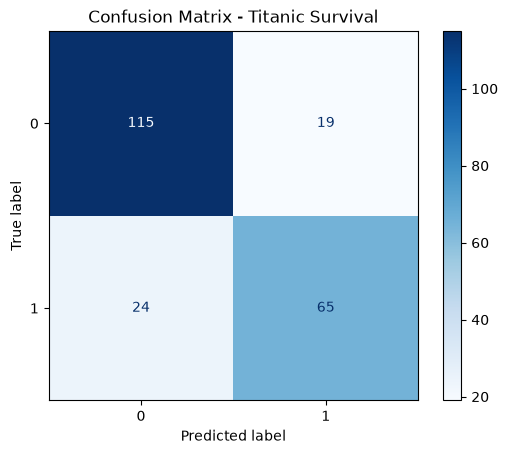

False Positives (Predicted survived, but didn't survive): 19
False Negatives (Predicted didn't survive, but did): 24


In [12]:
# TODO:
y_pred = pipeline.predict(X_test)
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=pipeline.classes_)
disp.plot(cmap='Blues')
plt.title('Confusion Matrix - Titanic Survival')
plt.show()
tn, fp, fn, tp = cm.ravel()
print(f"False Positives (Predicted survived, but didn't survive): {fp}")
print(f"False Negatives (Predicted didn't survive, but did): {fn}")

The model produced more false negatives than false positives. It incorrectly predicted that 24 passengers did not survive, while they actually survived. In comparison, it predicted 19 passengers as survivors even though they did not survive.

### 9. Classification report

> Print a classification report (precision, recall, f1-score) for the test set.

In [13]:
# TODO:
y_pred = pipeline.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.83      0.86      0.84       134
           1       0.77      0.73      0.75        89

    accuracy                           0.81       223
   macro avg       0.80      0.79      0.80       223
weighted avg       0.81      0.81      0.81       223



# Interpretation & Predictions

### 10. Pull out your feature names and coefficients

> Your `ColumnTransformer` renames and reorders your columns when it transforms `X`, the numeric columns keep their original names, but the one-hot encoded categorical columns get new names like `Sex_male`. Before you can interpret any coefficient, you need to know which coefficient belongs to which feature.
>
> 1. Get the one-hot encoded feature names out of your fitted `ColumnTransformer` using:
>
>    `.named_steps['preprocessing'].named_transformers_['onehotencoder'].get_feature_names_out(cat_cols)`.
> 
> 2. Combine these with your numeric column names, **in the same order your `ColumnTransformer` outputs them** (e.g. numeric columns first, then categorical).
> 
> 3. Pair these feature names with your fitted model's `.coef_[0]` values in a `pandas.Series` (feature names as the index), so you can look up any coefficient by name.

In [14]:
# TODO:
ohe_feature_names = (
    pipeline.named_steps['preprocessing']
    .named_transformers_['cat']
    .get_feature_names_out(cat_cols)
)
all_feature_names = num_cols + list(ohe_feature_names)
coefs = pipeline.named_steps['model'].coef_[0]
coefficients_series = pd.Series(coefs, index=all_feature_names)
print(coefficients_series)

Pclass       -0.774296
Age          -0.422135
SibSp        -0.312753
Parch        -0.092657
Fare          0.171213
Sex_male     -2.558772
Embarked_Q   -0.122718
Embarked_S   -0.419018
dtype: float64


### 11. Interpret one coefficient

> Pick one feature and interpret its coefficient. Convert it from log-odds into an odds ratio (`np.exp(coef)`), and explain in a sentence what it does to the odds of survival.

In [15]:
# TODO:
feature_name = 'Sex_male'
log_odds = coefficients_series[feature_name]
odds_ratio = np.exp(log_odds)

print(f"Log-odds for {feature_name}: {log_odds:.2f}")
print(f"Odds Ratio for {feature_name}: {odds_ratio:.2f}")

Log-odds for Sex_male: -2.56
Odds Ratio for Sex_male: 0.08


### 12. Generate predictions and predicted probabilities

> Use your model to generate `.predict()` and `.predict_proba()` on the test set. Pick one test observation and explain, in a sentence, what its predicted probability means.

In [16]:
# TODO:
y_pred = pipeline.predict(X_test)
y_proba = pipeline.predict_proba(X_test)

sample_idx = 0
sample_proba_survived = y_proba[sample_idx, 1]

print(f"Predicted Probability of Survival: {sample_proba_survived:.2f}")

Predicted Probability of Survival: 0.11


For this passenger, the model estimates an 11% probability of survival. Since this probability is below the 50% classification threshold, the model classifies the passenger as Did Not Survive.

### 12. Try a different threshold

> `.predict()` uses a default threshold of 0.5 on `.predict_proba()` to decide the class. Try lowering it and recompute the confusion matrix and classification report at this new threshold. What trade-off do you see between precision and recall?

In [17]:
# TODO:
threshold = 0.35
y_pred_new_threshold = (y_proba[:, 1] >= threshold).astype(int)

print(F"Confusion Matrix Threshold: {confusion_matrix(y_test, y_pred_new_threshold)}")
print(F"Classification Report Threshold: {classification_report(y_test, y_pred_new_threshold)}")

Confusion Matrix Threshold: [[104  30]
 [ 14  75]]
Classification Report Threshold:               precision    recall  f1-score   support

           0       0.88      0.78      0.83       134
           1       0.71      0.84      0.77        89

    accuracy                           0.80       223
   macro avg       0.80      0.81      0.80       223
weighted avg       0.81      0.80      0.80       223



Lowering the classification threshold from 0.5 to 0.35 improved the model’s Recall from 0.73 to 0.84, meaning it was able to identify more actual survivors and reduce the number of False Negatives. However, this improvement came at the cost of Precision, which decreased from 0.77 to 0.71, as the model incorrectly classified more non-survivors as survivors (more False Positives).

### 13. Write a function to print classification metrics with explanations

> Write a function `print_classification_metrics(y_true, y_pred)` that calculates **accuracy**, **recall/sensitivity**, **precision**, **specificity**, and **F1 score**, and prints each metric alongside a clear explanation. Then call your function on your model's test set predictions.
>
> Use the confusion matrix layout below as your reference for which cells (`TP`, `TN`, `FP`, `FN`) each metric is built from.

**Accuracy** — Overall, how often is the classifier correct?

<table style="border: none">
<tr style="border: none">
    <td style="border: none; vertical-align: bottom; color: blue">n</td>
    <td><b>Predicted: Did Not Survive (0)</b></td>
    <td><b>Predicted: Survived (1)</b></td>
</tr>
<tr>
    <td><b>Actual: Did Not Survive (0)</b></td>
    <td style="text-align: center; background-color: red">TN</td>
    <td style="text-align: center">FP</td>
</tr>
<tr>
    <td><b>Actual: Survived (1)</b></td>
    <td style="text-align: center">FN</td>
    <td style="text-align: center; background-color: green">TP</td>
</tr>
</table>

$$\textbf{Accuracy} = \frac{TP + TN}{Total}$$

**Recall / Sensitivity / True Positive Rate (TPR)** — Among all passengers who actually survived, what proportion did we correctly detect?

<table style="border: none">
<tr style="border: none">
    <td style="border: none; vertical-align: bottom; color: blue">n</td>
    <td><b>Predicted: Did Not Survive (0)</b></td>
    <td><b>Predicted: Survived (1)</b></td>
</tr>
<tr>
    <td><b>Actual: Did Not Survive (0)</b></td>
    <td style="text-align: center">TN</td>
    <td style="text-align: center">FP</td>
</tr>
<tr>
    <td><b>Actual: Survived (1)</b></td>
    <td style="text-align: center; background-color: orchid">FN</td>
    <td style="text-align: center; background-color: green">TP</td>
</tr>
</table>

$$\textbf{Recall} = \frac{TP}{TP + FN}$$

**Precision** — Among all passengers predicted to survive, what proportion actually did?

<table style="border: none">
<tr style="border: none">
    <td style="border: none; vertical-align: bottom; color: blue">n</td>
    <td><b>Predicted: Did Not Survive (0)</b></td>
    <td><b>Predicted: Survived (1)</b></td>
</tr>
<tr>
    <td><b>Actual: Did Not Survive (0)</b></td>
    <td style="text-align: center">TN</td>
    <td style="text-align: center; background-color: orange">FP</td>
</tr>
<tr>
    <td><b>Actual: Survived (1)</b></td>
    <td style="text-align: center">FN</td>
    <td style="text-align: center; background-color: green">TP</td>
</tr>
</table>

$$\textbf{Precision} = \frac{TP}{TP + FP}$$

**Specificity / True Negative Rate (TNR)** — Among all passengers who did not actually survive, what proportion did we correctly detect?

<table style="border: none">
<tr style="border: none">
    <td style="border: none; vertical-align: bottom; color: blue">n</td>
    <td><b>Predicted: Did Not Survive (0)</b></td>
    <td><b>Predicted: Survived (1)</b></td>
</tr>
<tr>
    <td><b>Actual: Did Not Survive (0)</b></td>
    <td style="text-align: center; background-color: red">TN</td>
    <td style="text-align: center; background-color: orange">FP</td>
</tr>
<tr>
    <td><b>Actual: Survived (1)</b></td>
    <td style="text-align: center">FN</td>
    <td style="text-align: center">TP</td>
</tr>
</table>

$$\textbf{Specificity} = \frac{TN}{TN + FP}$$

**$F_1$ score** — The balance between precision and recall.

<table style="border: none">
<tr style="border: none">
    <td style="border: none; vertical-align: bottom; color: blue">n</td>
    <td><b>Predicted: Did Not Survive (0)</b></td>
    <td><b>Predicted: Survived (1)</b></td>
</tr>
<tr>
    <td><b>Actual: Did Not Survive (0)</b></td>
    <td style="text-align: center">TN</td>
    <td style="text-align: center; background-color: orange">FP</td>
</tr>
<tr>
    <td><b>Actual: Survived (1)</b></td>
    <td style="text-align: center; background-color: orchid">FN</td>
    <td style="text-align: center; background-color: green">TP</td>
</tr>
</table>

$$F_1 = 2 \cdot \frac{Precision \cdot Recall}{Precision + Recall}$$


In [18]:
# TODO:
def print_classification_metrics(y_true, y_pred):
   
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()
    total = tn + fp + fn + tp

    accuracy = (tp + tn) / total
    recall = tp / (tp + fn) 
    precision = tp / (tp + fp) 
    specificity = tn / (tn + fp) 
    f1 = 2 * (precision * recall) / (precision + recall)

    print(f"Accuracy    : {accuracy:.2f} - Overall, how often is the classifier correct?")
    print(f"Recall      : {recall:.2f} - Among all passengers who actually survived, what proportion did we correctly detect?")
    print(f"Precision   : {precision:.2f} - Among all predicted survivors, what proportion actually survived?")
    print(f"Specificity : {specificity:.2f} - Among all passengers who did not actually survive, what proportion did we correctly detect?")
    print(f"F1 Score    : {f1:.2f} - The Balance between Precision and Recall.")
   


print_classification_metrics(y_test, y_pred)

Accuracy    : 0.81 - Overall, how often is the classifier correct?
Recall      : 0.73 - Among all passengers who actually survived, what proportion did we correctly detect?
Precision   : 0.77 - Among all predicted survivors, what proportion actually survived?
Specificity : 0.86 - Among all passengers who did not actually survive, what proportion did we correctly detect?
F1 Score    : 0.75 - The Balance between Precision and Recall.
